In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from matplotlib import pyplot as plt

In [ ]:
df = pd.read_csv('../data/short_ships(in with date).csv')
df = df[df["SHIPS_TIME"] <= 36]
df = df[df["SHIPS_TIME"] >= 0]
df["SHIPS_stormbasin"].value_counts()

SHIPS_stormbasin
EP    120099
AL     96950
CP      6972
Name: count, dtype: int64

In [4]:
# find vmax over the first 12 hours for each storm case
VMAX12_df = df[df["SHIPS_TIME"] <= 12][["SHIPS_case", "SHIPS_VMAX"]].groupby("SHIPS_case").max(min_count=3).rename(columns={"SHIPS_VMAX": "VMAX12"})
VMAX12_df

,VMAX12
SHIPS_case,
0,30.0
1,40.0
2,50.0
3,75.0
4,75.0
...,...
31998,40.0
31999,35.0
32000,35.0


In [5]:
MSLP12_df = df[df["SHIPS_TIME"] <= 12][["SHIPS_case", "SHIPS_MSLP"]].groupby("SHIPS_case").min(min_count=3).rename(columns={"SHIPS_MSLP": "MSLP12"})
MSLP12_df

,MSLP12
SHIPS_case,
0,1003.0
1,1001.0
2,995.0
3,985.0
4,985.0
...,...
31998,1005.0
31999,1006.0
32000,1006.0


In [6]:
POT_df = df[df["SHIPS_TIME"] == 12][["SHIPS_case", "SHIPS_VMPI", "SHIPS_VMAX"]]
POT_df["POT12"] = POT_df["SHIPS_VMPI"] - POT_df["SHIPS_VMAX"]
POT_df = POT_df[["SHIPS_case", "POT12"]].set_index("SHIPS_case")
POT_df

,POT12
SHIPS_case,
0,87.0
1,77.0
2,71.0
3,30.0
4,35.0
...,...
31998,104.0
31999,111.0
32000,105.0


In [22]:
VMAX36_df = df[df["SHIPS_TIME"] > 12][["SHIPS_case", "SHIPS_VMAX"]].groupby("SHIPS_case").max(min_count=4).rename(columns={"SHIPS_VMAX": "VMAX36"})
VMAX36_df

,VMAX36
SHIPS_case,
0,75.0
1,75.0
2,75.0
3,65.0
4,55.0
...,...
31998,NaN
31999,NaN
32000,NaN


In [8]:
V12_df = df[df["SHIPS_TIME"] == 12][["SHIPS_case", "SHIPS_VMAX"]].groupby("SHIPS_case").first()
V6_df = df[df["SHIPS_TIME"] == 6][["SHIPS_case", "SHIPS_VMAX"]].groupby("SHIPS_case").first()
V0_df = df[df["SHIPS_TIME"] == 0][["SHIPS_case", "SHIPS_VMAX"]].groupby("SHIPS_case").first()

VGRAD_df = V6_df.join(V12_df, on="SHIPS_case", lsuffix="6", rsuffix="12").join(V0_df, on="SHIPS_case").rename(columns={"SHIPS_VMAX": "SHIPS_VMAX0"})
VGRAD_df["VGRAD0-6"] = VGRAD_df["SHIPS_VMAX6"] - VGRAD_df["SHIPS_VMAX0"]
VGRAD_df["VGRAD6-12"] = VGRAD_df["SHIPS_VMAX12"] - VGRAD_df["SHIPS_VMAX6"]
VGRAD_df["VlogGRAD6-12"] = np.log(VGRAD_df["SHIPS_VMAX12"]) - np.log(VGRAD_df["SHIPS_VMAX6"])

VGRAD_df
VGRAD_df.drop(axis=1, labels=["SHIPS_VMAX12", "SHIPS_VMAX6", "SHIPS_VMAX0"], inplace=True)

In [9]:
''.join(list(str(1.982060e+11))[4:6])

'06'

In [10]:
cases = df[["SHIPS_case", "SHIPS_stormyear", "SHIPS_stormbasin", "SHIPS_stormid", "SHIPS_yyyymmddhhmm"]].groupby("SHIPS_case").first().rename(columns={"SHIPS_stormyear": "Year", "SHIPS_stormbasin": "Basin", "SHIPS_stormid": "StormID"})
cases["month"] = 0
for i in range(len(cases)):
    cases.at[i, "month"] = ''.join(list(str(cases.iloc[i]["SHIPS_yyyymmddhhmm"]))[4:6])
cases["day"] = 1
cases["Date"] = pd.to_datetime(cases[["month", "Year", "day"]])
cases.drop(columns=["month", "Year", "day", "SHIPS_yyyymmddhhmm"], inplace=True)

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_24502/3936499099.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '06' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cases.at[i, "month"] = ''.join(list(str(cases.iloc[i]["SHIPS_yyyymmddhhmm"]))[4:6])


In [24]:
data = cases.join(VMAX12_df, on="SHIPS_case").join(MSLP12_df, on="SHIPS_case").join(POT_df, on="SHIPS_case").join(VGRAD_df, on="SHIPS_case").join(VMAX36_df, on="SHIPS_case")
data = data.groupby("StormID").first().dropna()
print(data["Basin"].value_counts())
data.columns
data

Basin
EP    555
AL    548
CP     23
Name: count, dtype: int64


,Basin,Date,VMAX12,MSLP12,POT12,VGRAD0-6,VGRAD6-12,VlogGRAD6-12,VMAX36
StormID,,,,,,,,,
AL011982,AL,1982-06-01,30.0,1003.0,87.0,5.0,5.0,0.182322,75.0
AL011985,AL,1985-07-01,30.0,1011.0,89.0,0.0,0.0,0.000000,40.0
AL011986,AL,1986-06-01,30.0,1005.0,72.0,0.0,0.0,0.000000,45.0
AL011988,AL,1988-08-01,20.0,1013.0,106.0,0.0,0.0,0.000000,30.0
AL011991,AL,1991-07-01,25.0,1010.0,85.0,0.0,0.0,0.000000,45.0
...,...,...,...,...,...,...,...,...,...
EP241992,EP,1992-10-01,30.0,1007.0,118.0,5.0,0.0,0.000000,50.0
EP242018,EP,2018-10-01,35.0,1005.0,136.0,0.0,5.0,0.154151,85.0
EP252018,EP,2018-11-01,35.0,1006.0,130.0,0.0,5.0,0.154151,50.0


In [25]:
oni = pd.read_csv("../data/oni.csv")
oni.rename(columns={"  ONI from CPC  missing value -99.9 https://psl.noaa.gov/data/timeseries/month/": "ONI"}, inplace=True)
oni = oni[pd.to_datetime(oni["Date"]) <= pd.to_datetime("01-01-2023")]
oni = oni[pd.to_datetime(oni["Date"]) >= pd.to_datetime("01-01-1981")]
oni["Date"] = pd.to_datetime(oni["Date"])
data["Date"] = pd.to_datetime(data["Date"])
oni.set_index("Date", inplace=True)
data.set_index("Date", inplace=True)
data = data.join(oni, how="left")
data

,Basin,VMAX12,MSLP12,POT12,VGRAD0-6,VGRAD6-12,VlogGRAD6-12,VMAX36,ONI
Date,,,,,,,,,
1982-06-01,AL,30.0,1003.0,87.0,5.0,5.0,0.182322,75.0,0.72
1985-07-01,AL,30.0,1011.0,89.0,0.0,0.0,0.000000,40.0,-0.49
1986-06-01,AL,30.0,1005.0,72.0,0.0,0.0,0.000000,45.0,-0.04
1988-08-01,AL,20.0,1013.0,106.0,0.0,0.0,0.000000,30.0,-1.11
1991-07-01,AL,25.0,1010.0,85.0,0.0,0.0,0.000000,45.0,0.73
...,...,...,...,...,...,...,...,...,...
1992-10-01,EP,30.0,1007.0,118.0,5.0,0.0,0.000000,50.0,-0.25
2018-10-01,EP,35.0,1005.0,136.0,0.0,5.0,0.154151,85.0,0.81
2018-11-01,EP,35.0,1006.0,130.0,0.0,5.0,0.154151,50.0,0.97


In [26]:
cols_to_log = ['VMAX12', 'MSLP12', 'POT12', 'VMAX36']
for col in cols_to_log:
    data[f"log{col}"] = np.log(data[col])
data

,Basin,VMAX12,MSLP12,POT12,VGRAD0-6,VGRAD6-12,VlogGRAD6-12,VMAX36,ONI,logVMAX12,logMSLP12,logPOT12,logVMAX36
Date,,,,,,,,,,,,,
1982-06-01,AL,30.0,1003.0,87.0,5.0,5.0,0.182322,75.0,0.72,3.401197,6.910751,4.465908,4.317488
1985-07-01,AL,30.0,1011.0,89.0,0.0,0.0,0.000000,40.0,-0.49,3.401197,6.918695,4.488636,3.688879
1986-06-01,AL,30.0,1005.0,72.0,0.0,0.0,0.000000,45.0,-0.04,3.401197,6.912743,4.276666,3.806662
1988-08-01,AL,20.0,1013.0,106.0,0.0,0.0,0.000000,30.0,-1.11,2.995732,6.920672,4.663439,3.401197
1991-07-01,AL,25.0,1010.0,85.0,0.0,0.0,0.000000,45.0,0.73,3.218876,6.917706,4.442651,3.806662
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992-10-01,EP,30.0,1007.0,118.0,5.0,0.0,0.000000,50.0,-0.25,3.401197,6.914731,4.770685,3.912023
2018-10-01,EP,35.0,1005.0,136.0,0.0,5.0,0.154151,85.0,0.81,3.555348,6.912743,4.912655,4.442651
2018-11-01,EP,35.0,1006.0,130.0,0.0,5.0,0.154151,50.0,0.97,3.555348,6.913737,4.867534,3.912023


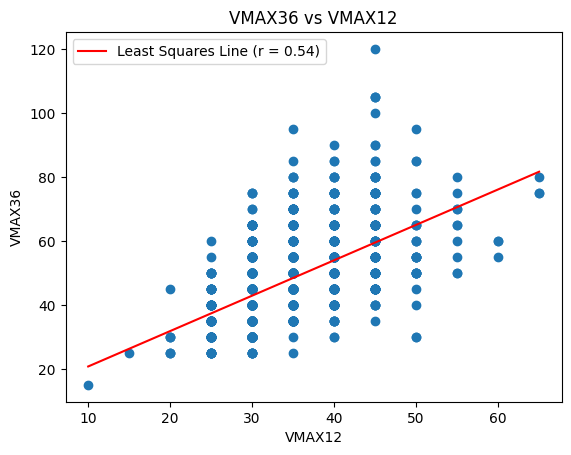

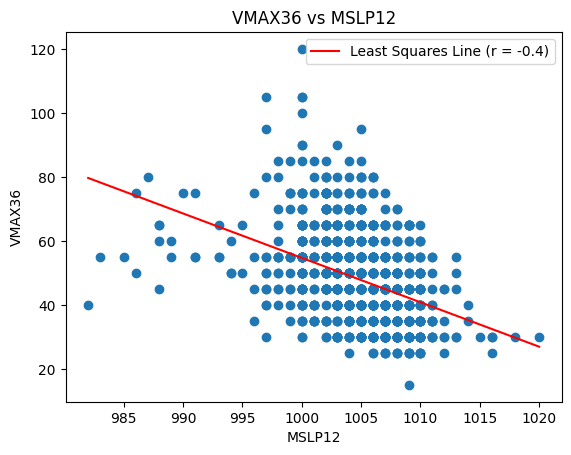

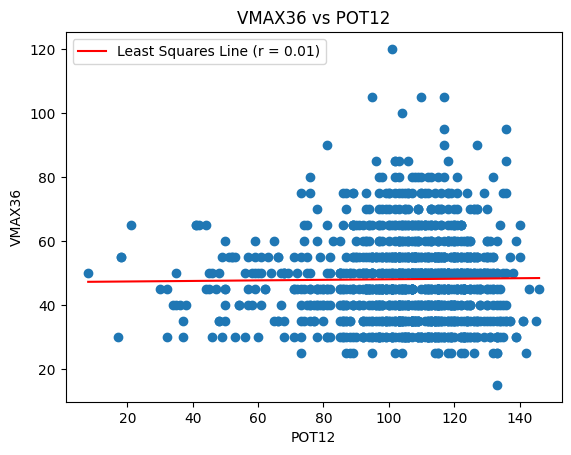

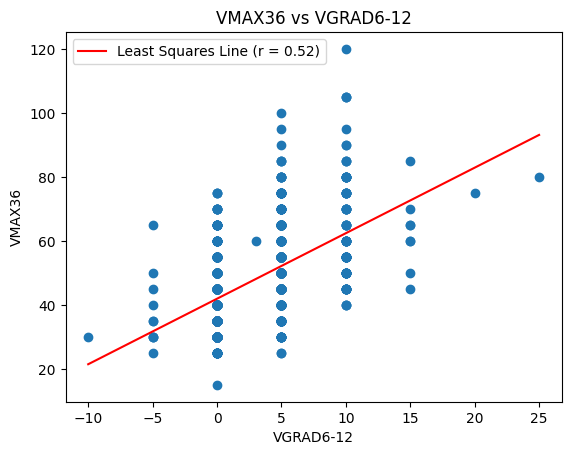

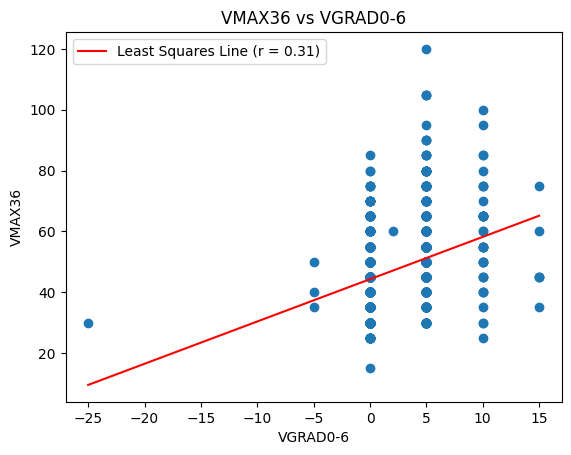

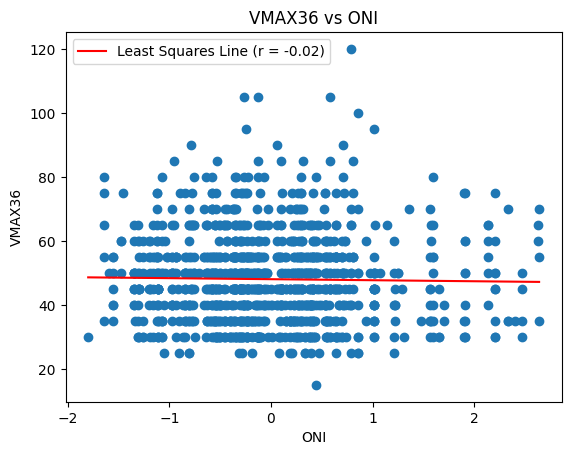

In [27]:
cols_to_test = ['VMAX12', 'MSLP12', 'POT12', 'VGRAD6-12', 'VGRAD0-6', 'ONI']
for col in cols_to_test:
    reg = stats.linregress(data[col], data["VMAX36"])
    domain = np.linspace(min(data[col]), max(data[col]), 200)
    plt.title(f"VMAX36 vs {col}")
    plt.xlabel(col)
    plt.ylabel("VMAX36")
    plt.plot(domain, reg[0]*domain + reg[1], color='red', label=f'Least Squares Line (r = {np.round(reg[2], 2)})')
    plt.scatter(data[col], data["VMAX36"])
    plt.legend()
    plt.show()

In [15]:
data.columns

Index(['Basin', 'VMAX12', 'MSLP12', 'POT12', 'VGRAD0-6', 'VGRAD6-12',
       'VlogGRAD6-12', 'VMAX60', 'ONI', 'logVMAX12', 'logMSLP12', 'logPOT12',
       'logVMAX60'],
      dtype='object')

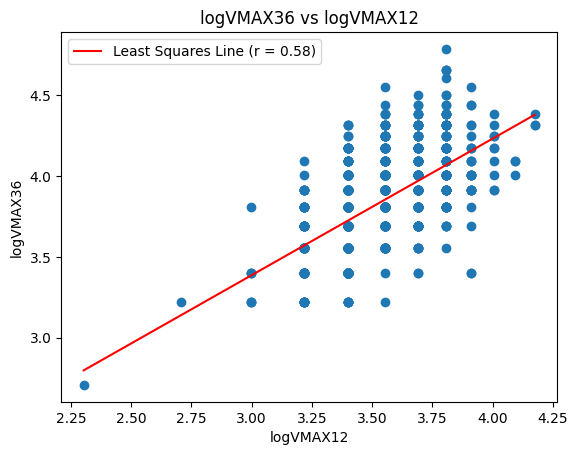

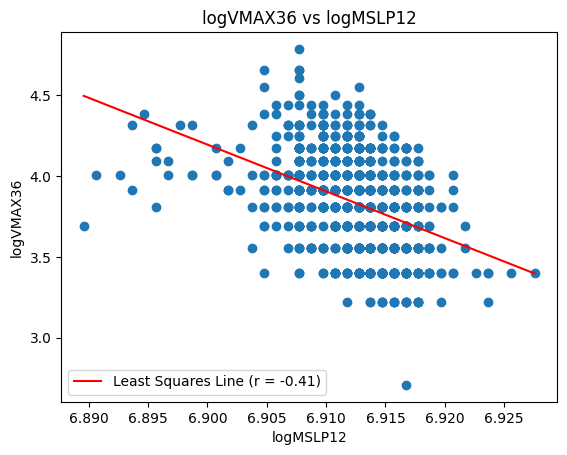

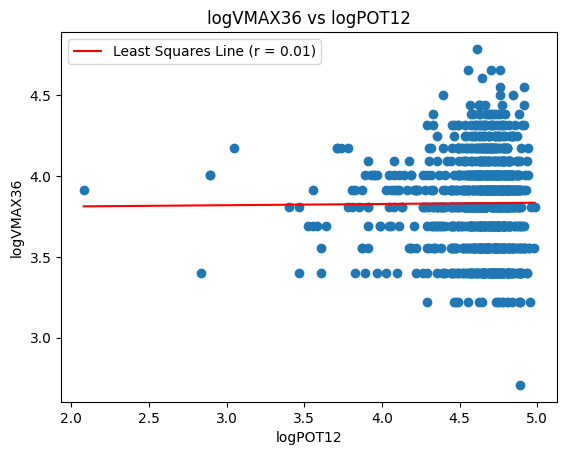

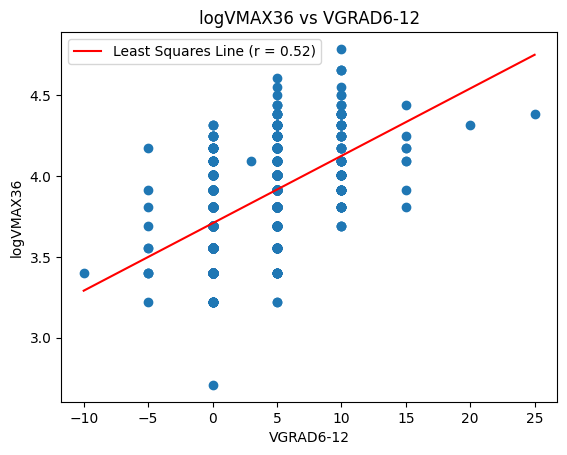

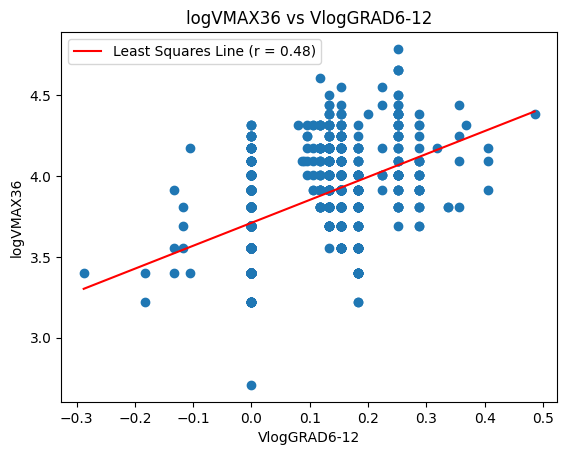

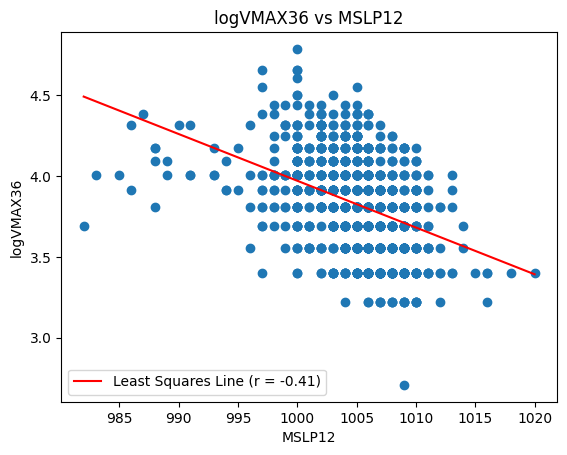

In [28]:
cols_to_test2 = ['logVMAX12', 'logMSLP12', 'logPOT12', "VGRAD6-12", "VlogGRAD6-12", "MSLP12"]
for col in cols_to_test2:
    reg = stats.linregress(data[col], data["logVMAX36"])
    domain = np.linspace(min(data[col]), max(data[col]), 200)
    plt.title(f"logVMAX36 vs {col}")
    plt.xlabel(col)
    plt.ylabel("logVMAX36")
    plt.plot(domain, reg[0]*domain + reg[1], color='red', label=f'Least Squares Line (r = {np.round(reg[2], 2)})')
    plt.scatter(data[col], data["logVMAX36"])
    plt.legend()
    plt.show()

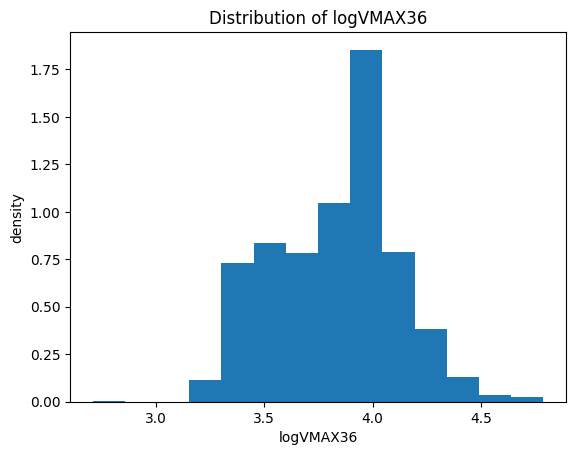

In [30]:
plt.hist(data["logVMAX36"], bins=14, density=True)
plt.title("Distribution of logVMAX36")
plt.xlabel("logVMAX36")
plt.ylabel("density")
plt.show()

In [37]:
data_final = data.drop(axis=1, labels=["VlogGRAD6-12", "VGRAD0-6"])
data_final.to_csv("../data/processed_data.csv")

In [ ]:
data_final["Basin"].value_counts()

Basin
EP    555
AL    548
CP     23
Name: count, dtype: int64